<a href="https://colab.research.google.com/github/AnisaIntania/Desain-dan-Analisis-Algoritma/blob/main/DL_P4_Sesi_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch torchvision scikit-learn matplotlib tqdm

In [ ]:
%%writefile lab_cifar10_pycharm.py
"""
PyCharm Lab Script — CIFAR-10 CNN (Medium Difficulty)
======================================================================
Variants (dilatih berurutan):
 1) max_flatten
 2) avg_flatten
 3) max_gap
 4) avg_gap

Artifacts disimpan ke --outdir (default: runs_cifar10):
 - results.csv
 - logs/<varian>_curves.png
 - confusion_matrices/<varian>_confmat.png
 - feature_maps/<best>_block1.png dan <best>_block3.png
 - gradcam/<best>/{correct_*.png, wrong_*.png}
"""

import os, csv, random, argparse
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils as tvutils
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


def pick_device(device_arg: str):
    if device_arg == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        try:
            if torch.backends.mps.is_available():
                return torch.device("mps")
        except Exception:
            pass
        return torch.device("cpu")
    elif device_arg == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    elif device_arg == "mps":
        try:
            return torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        except Exception:
            return torch.device("cpu")
    else:
        return torch.device("cpu")


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool='max'):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
        if pool == 'max':
            self.pool = nn.MaxPool2d(2)
        elif pool == 'avg':
            self.pool = nn.AvgPool2d(2)
        else:
            raise ValueError("pool must be 'max' or 'avg'")

    def forward(self, x):
        x = self.conv(x); x = self.bn(x); x = self.act(x); x = self.pool(x)
        return x


class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, pool='max', head='flatten'):
        super().__init__()
        self.block1 = ConvBlock(3, 32, pool)
        self.block2 = ConvBlock(32, 64, pool)
        self.block3 = ConvBlock(64, 128, pool)
        self.head_type = head
        if head == 'flatten':
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 4 * 4, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )
        elif head == 'gap':
            self.gap = nn.AdaptiveAvgPool2d(1)
            self.head = nn.Linear(128, num_classes)
        else:
            raise ValueError("head must be 'flatten' or 'gap'")

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        feats = x
        if self.head_type == 'flatten':
            logits = self.head(x)
        else:
            x = self.gap(x)
            logits = self.head(x.flatten(1))
        return logits, feats


def build_loaders(batch_size: int, workers: int = 2):
    mean, std = [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    train_ds = datasets.CIFAR10(root="./data", train=True, transform=train_tf, download=True)
    test_ds = datasets.CIFAR10(root="./data", train=False, transform=test_tf, download=True)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
    test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)
    return train_ld, test_ld, train_ds.classes


def evaluate(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            pred = logits.argmax(1).cpu().tolist()
            y_pred += pred
            y_true += y.tolist()
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    return acc, f1, cm


def train_epochs(model, train_ld, test_ld, device, epochs=4, lr=3e-4, tag="model", outdir="runs_cifar10"):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    tr_losses, te_accs, te_f1s = [], [], []
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for x, y in tqdm(train_ld, leave=False, desc=f"train {tag} ep{ep}"):
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss.backward()
            opt.step()
            running += loss.item() * x.size(0)
        tr_loss = running / len(train_ld.dataset)
        acc, f1, _ = evaluate(model, test_ld, device)
        tr_losses.append(tr_loss); te_accs.append(acc); te_f1s.append(f1)
        print(f"[{tag}] Epoch {ep}: train_loss={tr_loss:.4f} test_acc={acc:.4f} test_f1={f1:.4f}")
    os.makedirs(os.path.join(outdir, "logs"), exist_ok=True)
    plt.figure()
    plt.plot(tr_losses, label='train_loss')
    plt.plot(te_accs, label='test_acc')
    plt.plot(te_f1s, label='test_f1')
    plt.legend(); plt.xlabel('epoch')
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "logs", f"{tag}_curves.png"), dpi=200)
    plt.close()
    return model


def denorm(img_t, mean, std):
    m = torch.tensor(mean)[:, None, None]
    s = torch.tensor(std)[:, None, None]
    return (img_t.cpu() * s + m).clamp(0, 1)


@torch.no_grad()
def save_feature_maps(model, loader, device, outdir, tag="model", layer_name='block1', n_ch=8):
    mean, std = [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]
    model = model.to(device)
    model.eval()
    imgs, _ = next(iter(loader))
    x = imgs[:1].to(device)
    feats = {}

    def _capture_hook(m, i, o):
        feats['f'] = o.detach().cpu()

    handle = getattr(model, layer_name).register_forward_hook(_capture_hook)
    _ = model(x); handle.remove()
    fm = feats['f'][0]
    idx = torch.linspace(0, fm.shape[0] - 1, steps=min(n_ch, fm.shape[0])).long()
    fm_sel = fm[idx].unsqueeze(1)
    grid = tvutils.make_grid(fm_sel, nrow=min(n_ch, 8), padding=2)
    grid = grid.permute(1, 2, 0).cpu().numpy()
    fig = plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(denorm(imgs[0], mean, std).permute(1, 2, 0))
    plt.title("Input"); plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(grid.squeeze())
    plt.title(f"Feature maps: {layer_name}"); plt.axis("off")
    os.makedirs(os.path.join(outdir, "feature_maps"), exist_ok=True)
    out = os.path.join(outdir, "feature_maps", f"{tag}_{layer_name}.png")
    plt.tight_layout(); plt.savefig(out, dpi=200); plt.close()
    return out


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target = target_layer
        self.activations = None
        self.gradients = None
        self.hook_a = self.target.register_forward_hook(self._forward_hook)
        self.hook_g = self.target.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, m, i, o):
        self.activations = o

    def _backward_hook(self, m, gi, go):
        self.gradients = go[0]

    def generate(self):
        w = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (w * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam_min = cam.amin(dim=(2, 3), keepdim=True)
        cam_max = cam.amax(dim=(2, 3), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-6)
        return cam

    def close(self):
        self.hook_a.remove(); self.hook_g.remove()


def overlay_cam(img_tensor, cam, mean, std):
    base = denorm(img_tensor, mean, std).permute(1, 2, 0).numpy()
    H, W = base.shape[:2]
    cam_up = F.interpolate(cam.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False)
    heat = cam_up.squeeze(0).squeeze(0).detach().cpu().numpy()
    heat = plt.cm.jet(heat)[..., :3]
    overlay = (0.4 * heat + 0.6 * base).clip(0, 1)
    return base, overlay


def save_gradcam_samples(model, loader, device, classes, outdir, tag="model", k_correct=3, k_wrong=3):
    mean, std = [0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010]
    os.makedirs(os.path.join(outdir, "gradcam", tag), exist_ok=True)
    model = model.to(device)
    model.eval()
    xs, ys, preds = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            pred = logits.argmax(1).cpu()
            xs.append(x.cpu()); ys.append(y); preds.append(pred)
    xs = torch.cat(xs); ys = torch.cat(ys); preds = torch.cat(preds)
    correct_idx = (preds == ys).nonzero().squeeze()[:k_correct]
    wrong_idx = (preds != ys).nonzero().squeeze()[:k_wrong]

    cammer = GradCAM(model, model.block3)

    def save_idxs(idxs, label_tag):
        for i, idx in enumerate(torch.atleast_1d(idxs)):
            img = xs[idx:idx + 1].to(device)
            lab = ys[idx].item()
            pr = preds[idx].item()
            score = model(img)[0][0, pr]
            model.zero_grad(set_to_none=True)
            score.backward(retain_graph=False)
            cam = cammer.generate()[0]
            base, ov = overlay_cam(img[0].cpu(), cam, mean, std)
            fig = plt.figure(figsize=(6, 3))
            plt.subplot(1, 2, 1)
            plt.imshow(base)
            plt.title(f"True: {classes[lab]} / Pred: {classes[pr]}")
            plt.axis("off")
            plt.subplot(1, 2, 2)
            plt.imshow(ov)
            plt.title("Grad-CAM"); plt.axis("off")
            out = os.path.join(outdir, "gradcam", tag, f"{label_tag}_{i}.png")
            plt.tight_layout(); plt.savefig(out, dpi=200); plt.close()

    save_idxs(correct_idx, "correct")
    save_idxs(wrong_idx, "wrong")
    cammer.close()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--outdir", type=str, default="runs_cifar10")
    parser.add_argument("--epochs", type=int, default=4)
    parser.add_argument("--batch_size", type=int, default=128)
    parser.add_argument("--lr", type=float, default=3e-4)
    parser.add_argument("--workers", type=int, default=2)
    parser.add_argument("--device", type=str, default="auto", choices=["auto", "cpu", "cuda", "mps"])
    parser.add_argument("--stage", type=str, default="all", choices=["all", "train", "viz"])
    args = parser.parse_args()

    device = pick_device(args.device)
    print("Using device:", device)

    os.makedirs(args.outdir, exist_ok=True)
    os.makedirs(os.path.join(args.outdir, "confusion_matrices"), exist_ok=True)
    ckpt_dir = os.path.join(args.outdir, "checkpoints")
    os.makedirs(ckpt_dir, exist_ok=True)

    variants = [
        ("max_flatten", dict(pool='max', head='flatten')),
        ("avg_flatten", dict(pool='avg', head='flatten')),
        ("max_gap", dict(pool='max', head='gap')),
        ("avg_gap", dict(pool='avg', head='gap')),
    ]

    if args.stage == "viz":
        csv_path = os.path.join(args.outdir, "results.csv")
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"{csv_path} not found. Run --stage all first.")
        with open(csv_path, newline="") as f:
            reader = csv.DictReader(f)
            results = [dict(variant=r["variant"], acc=float(r["acc"]), macro_f1=float(r["macro_f1"])) for r in reader]
        best_name = max(results, key=lambda r: r["acc"])["variant"]
        ckpt_path = os.path.join(ckpt_dir, f"{best_name}.pt")
        if not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"Checkpoint {ckpt_path} not found. Rerun with --stage all.")
        pool, head = best_name.split("_", 1)
        best_model = SmallCNN(num_classes=10, pool=pool, head=head).to(device)
        best_model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print("Loaded best model from checkpoint:", best_name)

        _, test_ld, classes = build_loaders(args.batch_size, args.workers)
        save_feature_maps(best_model, test_ld, device, args.outdir, tag=best_name, layer_name='block1', n_ch=8)
        save_feature_maps(best_model, test_ld, device, args.outdir, tag=best_name, layer_name='block3', n_ch=8)
        save_gradcam_samples(best_model, test_ld, device, classes, args.outdir, tag=best_name, k_correct=3, k_wrong=3)
        print("All done (viz stage). Artifacts in:", os.path.abspath(args.outdir))
        return

    train_ld, test_ld, classes = build_loaders(args.batch_size, args.workers)

    results = []
    models = {}
    for name, cfg in variants:
        print(f"\n=== Training {name} ===")
        model = SmallCNN(num_classes=10, **cfg).to(device)
        model = train_epochs(model, train_ld, test_ld, device, epochs=args.epochs, lr=args.lr, tag=name, outdir=args.outdir)
        acc, f1, cm = evaluate(model, test_ld, device)
        results.append(dict(variant=name, acc=acc, macro_f1=f1))
        models[name] = (model, cm)

        torch.save(model.state_dict(), os.path.join(ckpt_dir, f"{name}.pt"))

        disp = ConfusionMatrixDisplay(cm, display_labels=classes)
        fig, ax = plt.subplots(figsize=(5, 5))
        disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
        plt.title(f"{name} — Confusion Matrix")
        plt.tight_layout()
        plt.savefig(os.path.join(args.outdir, "confusion_matrices", f"{name}_confmat.png"), dpi=200)
        plt.close()

    csv_path = os.path.join(args.outdir, "results.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["variant", "acc", "macro_f1"])
        w.writeheader()
        for r in results:
            w.writerow(r)
    print("Saved:", csv_path)

    if args.stage == "train":
        print("Stage='train' finished. Run again with --stage viz.")
        return

    best_name = max(results, key=lambda r: r["acc"])["variant"]
    best_model = models[best_name][0]
    print("Best model:", best_name)

    try:
        save_feature_maps(best_model, test_ld, device, args.outdir, tag=best_name, layer_name='block1', n_ch=8)
        save_feature_maps(best_model, test_ld, device, args.outdir, tag=best_name, layer_name='block3', n_ch=8)
        save_gradcam_samples(best_model, test_ld, device, classes, args.outdir, tag=best_name, k_correct=3, k_wrong=3)
    except Exception as e:
        print("\n[WARNING] Feature maps/Grad-CAM step failed:", repr(e))
        print("results.csv, curves, and confusion matrices are already saved.")
        print(f"Checkpoint for '{best_name}' was saved — rerun with --stage viz, no retrain needed.")
        raise

    print("All done. Artifacts in:", os.path.abspath(args.outdir))


if __name__ == "__main__":
    main()

Writing lab_cifar10_pycharm.py


In [ ]:
!wc -l lab_cifar10_pycharm.py
!grep -n "F.interpolate" lab_cifar10_pycharm.py

395 lab_cifar10_pycharm.py
243:    cam_up = F.interpolate(cam.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False)


In [ ]:
!python lab_cifar10_pycharm.py --outdir runs_cifar10 --stage all

Using device: cuda
100% 170M/170M [41:38<00:00, 68.2kB/s]

=== Training max_flatten ===
[max_flatten] Epoch 1: train_loss=1.5041 test_acc=0.5835 test_f1=0.5748
[max_flatten] Epoch 2: train_loss=1.1596 test_acc=0.6668 test_f1=0.6653
[max_flatten] Epoch 3: train_loss=1.0355 test_acc=0.6806 test_f1=0.6791
[max_flatten] Epoch 4: train_loss=0.9588 test_acc=0.6966 test_f1=0.6964

=== Training avg_flatten ===
[avg_flatten] Epoch 1: train_loss=1.5392 test_acc=0.5586 test_f1=0.5556
[avg_flatten] Epoch 2: train_loss=1.2287 test_acc=0.6275 test_f1=0.6202
[avg_flatten] Epoch 3: train_loss=1.0789 test_acc=0.6622 test_f1=0.6580
[avg_flatten] Epoch 4: train_loss=0.9898 test_acc=0.6892 test_f1=0.6907

=== Training max_gap ===
[max_gap] Epoch 1: train_loss=1.6645 test_acc=0.4770 test_f1=0.4757
[max_gap] Epoch 2: train_loss=1.3551 test_acc=0.5371 test_f1=0.5294
[max_gap] Epoch 3: train_loss=1.2422 test_acc=0.5683 test_f1=0.5669
[max_gap] Epoch 4: train_loss=1.1680 test_acc=0.5893 test_f1=0.5880

=== Tra

In [ ]:
!find /content/runs_cifar10 -maxdepth 3 -type f | sort

/content/runs_cifar10/checkpoints/avg_flatten.pt
/content/runs_cifar10/checkpoints/avg_gap.pt
/content/runs_cifar10/checkpoints/max_flatten.pt
/content/runs_cifar10/checkpoints/max_gap.pt
/content/runs_cifar10/confusion_matrices/avg_flatten_confmat.png
/content/runs_cifar10/confusion_matrices/avg_gap_confmat.png
/content/runs_cifar10/confusion_matrices/max_flatten_confmat.png
/content/runs_cifar10/confusion_matrices/max_gap_confmat.png
/content/runs_cifar10/feature_maps/max_flatten_block1.png
/content/runs_cifar10/feature_maps/max_flatten_block3.png
/content/runs_cifar10/gradcam/max_flatten/correct_0.png
/content/runs_cifar10/gradcam/max_flatten/correct_1.png
/content/runs_cifar10/gradcam/max_flatten/correct_2.png
/content/runs_cifar10/gradcam/max_flatten/wrong_0.png
/content/runs_cifar10/gradcam/max_flatten/wrong_1.png
/content/runs_cifar10/gradcam/max_flatten/wrong_2.png
/content/runs_cifar10/logs/avg_flatten_curves.png
/content/runs_cifar10/logs/avg_gap_curves.png
/content/runs_cifa

In [ ]:
import os

for root, dirs, files in os.walk("runs_cifar10"):
    for file in files:
        if file.endswith(".png"):
            print(os.path.join(root, file))

runs_cifar10/gradcam/max_flatten/wrong_0.png
runs_cifar10/gradcam/max_flatten/wrong_1.png
runs_cifar10/gradcam/max_flatten/correct_1.png
runs_cifar10/gradcam/max_flatten/correct_2.png
runs_cifar10/gradcam/max_flatten/wrong_2.png
runs_cifar10/gradcam/max_flatten/correct_0.png
runs_cifar10/logs/max_gap_curves.png
runs_cifar10/logs/avg_flatten_curves.png
runs_cifar10/logs/max_flatten_curves.png
runs_cifar10/logs/avg_gap_curves.png
runs_cifar10/feature_maps/max_flatten_block3.png
runs_cifar10/feature_maps/max_flatten_block1.png
runs_cifar10/confusion_matrices/max_flatten_confmat.png
runs_cifar10/confusion_matrices/max_gap_confmat.png
runs_cifar10/confusion_matrices/avg_flatten_confmat.png
runs_cifar10/confusion_matrices/avg_gap_confmat.png


=== Feature Maps ===


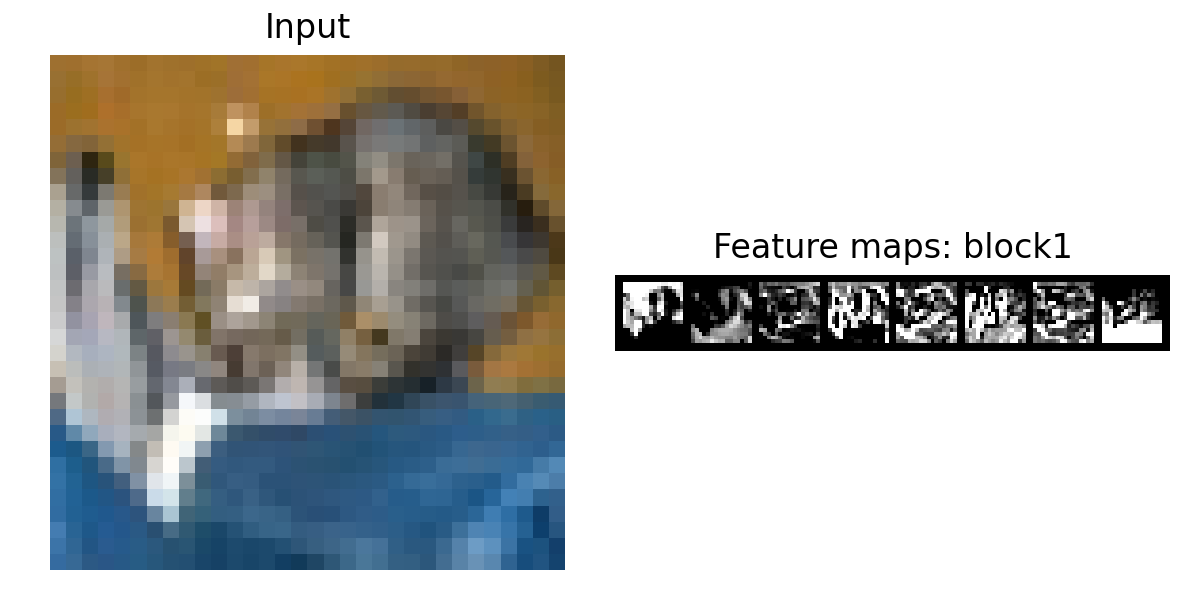

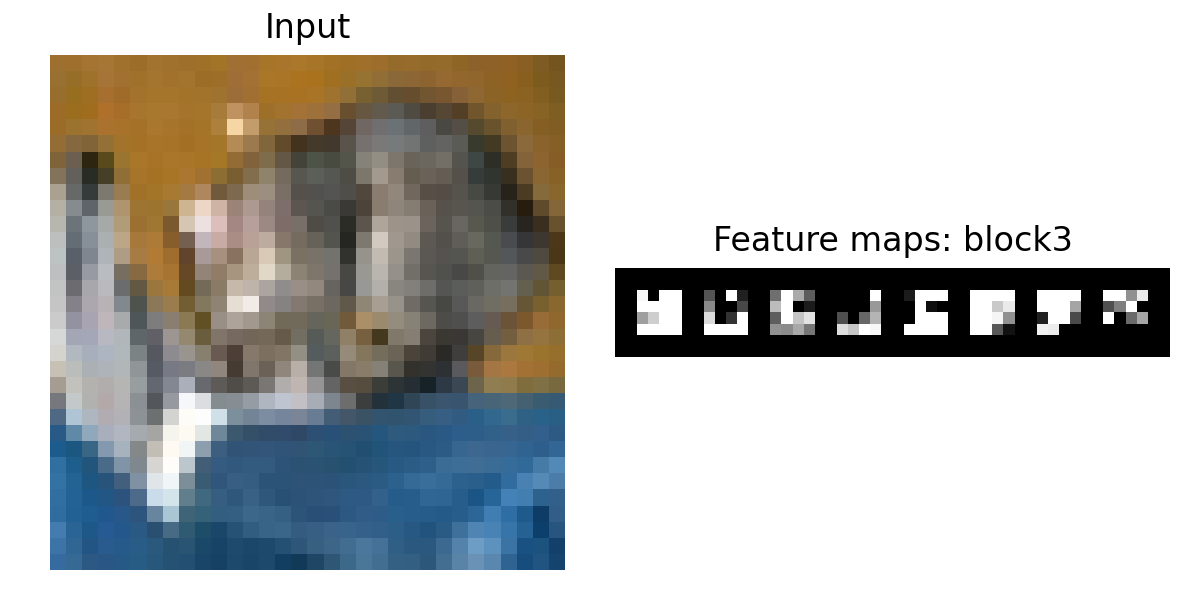

=== Grad-CAM: Prediksi BENAR ===


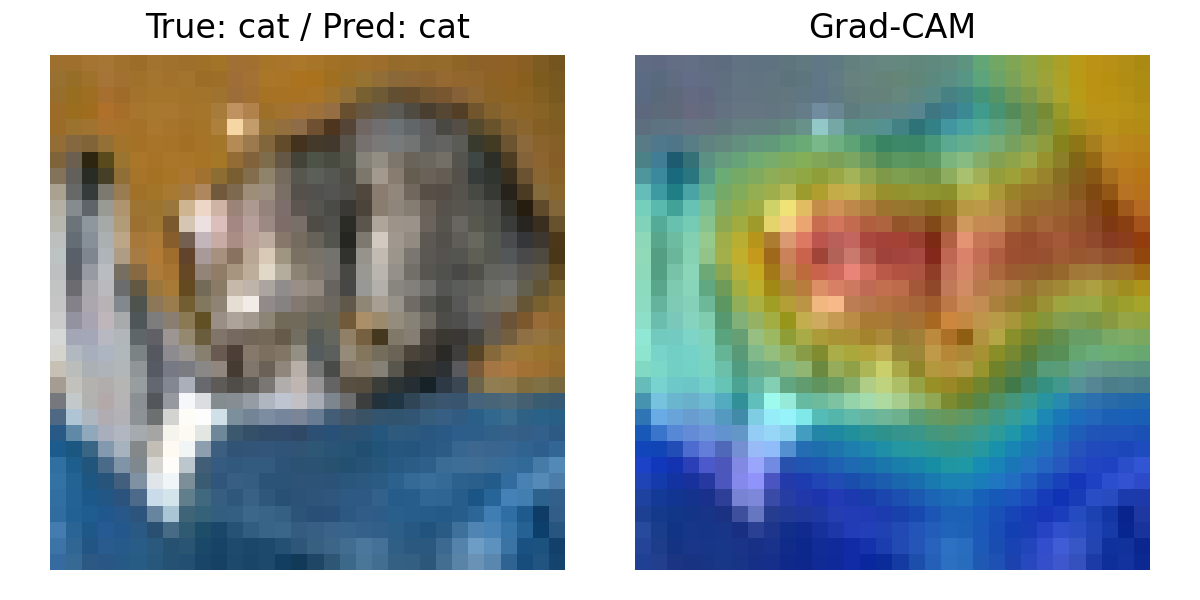

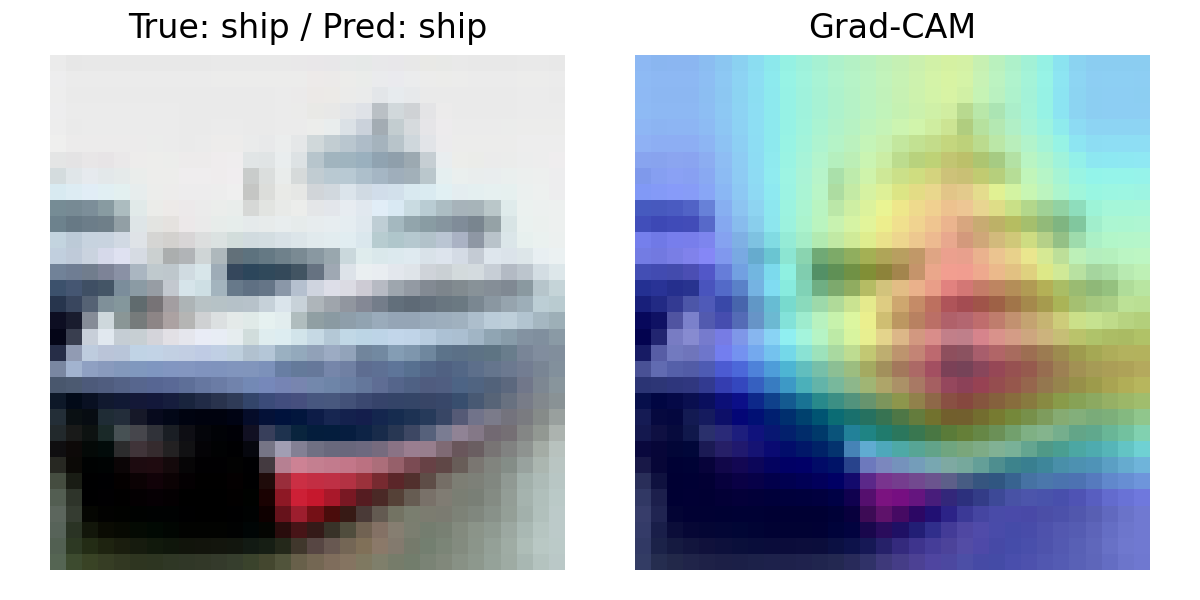

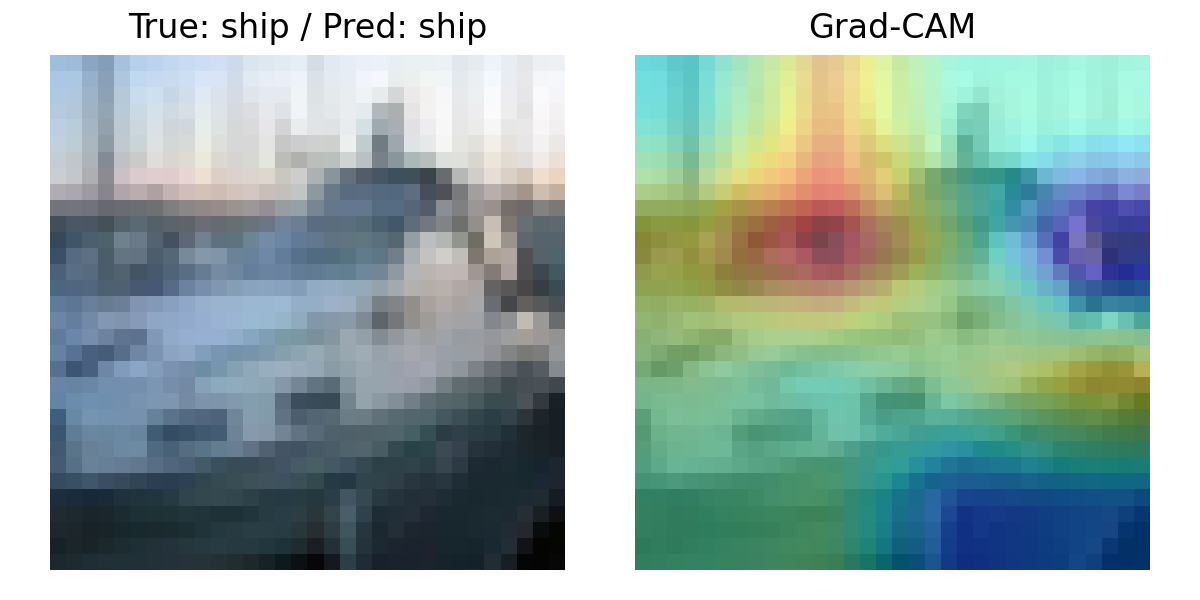

=== Grad-CAM: Prediksi SALAH ===


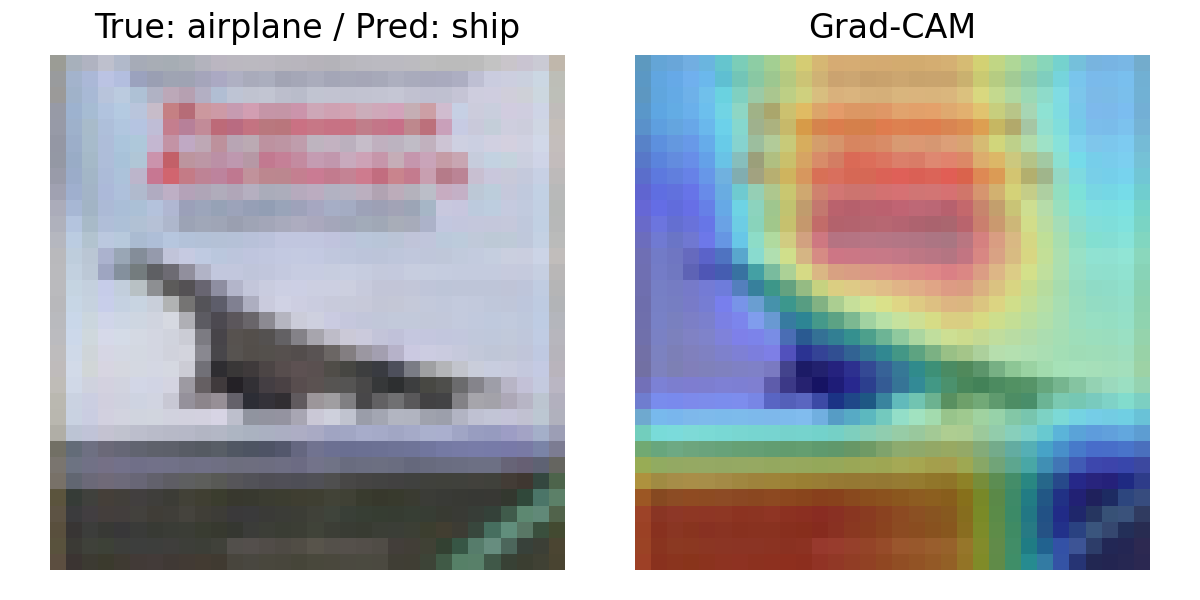

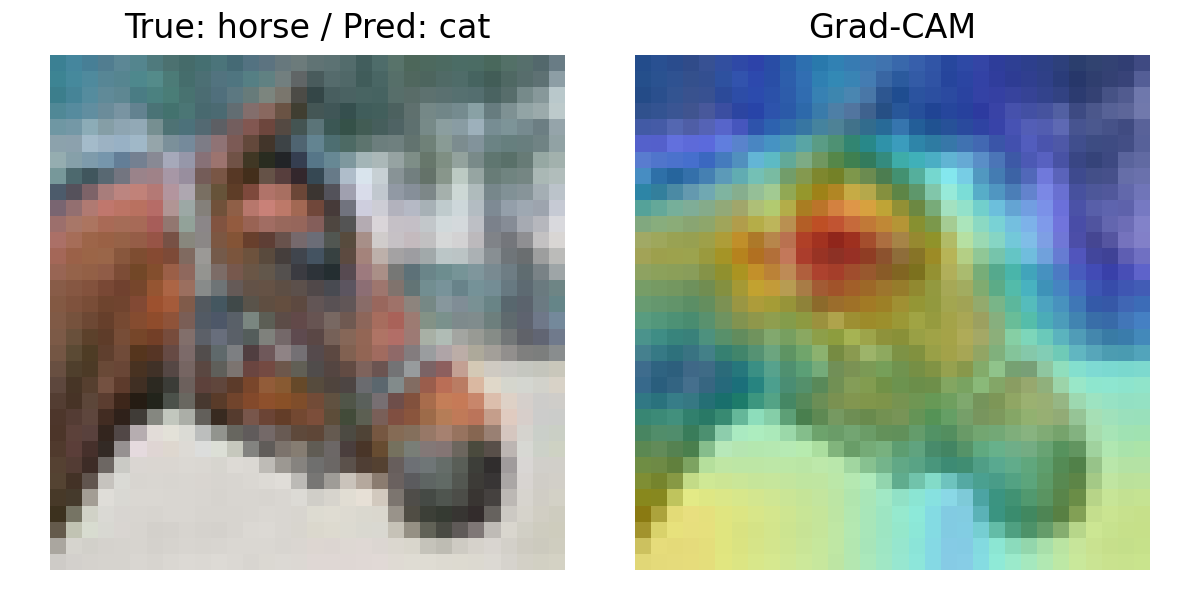

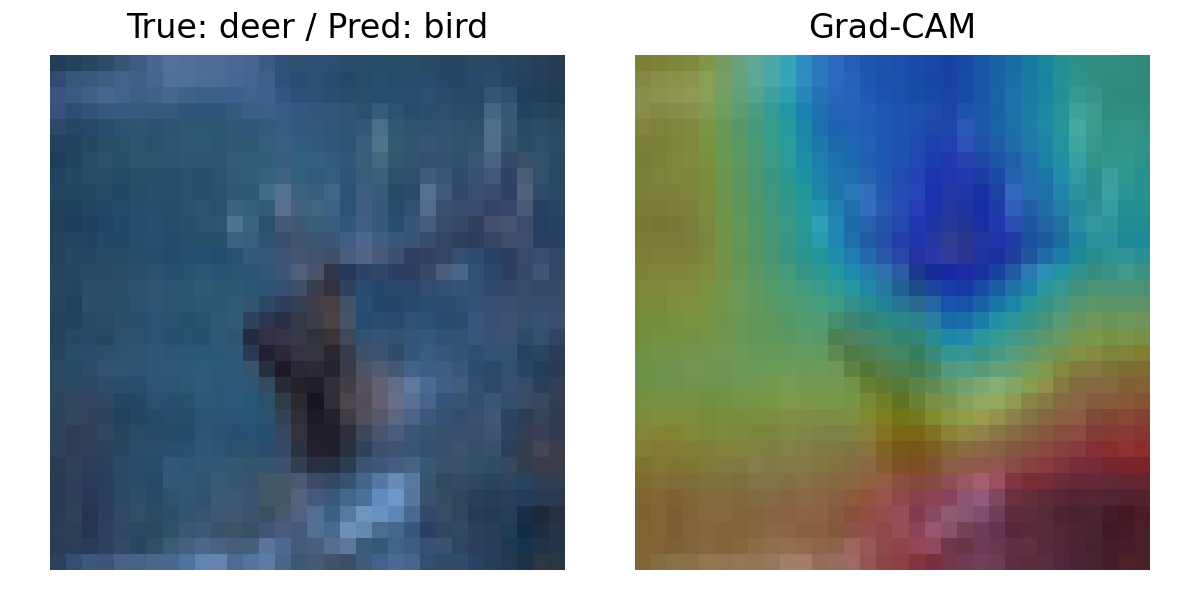

In [ ]:
from IPython.display import Image, display

best = "max_flatten"

print("=== Feature Maps ===")
display(Image(f'runs_cifar10/feature_maps/{best}_block1.png'))
display(Image(f'runs_cifar10/feature_maps/{best}_block3.png'))

print("=== Grad-CAM: Prediksi BENAR ===")
for i in range(3):
    display(Image(f'runs_cifar10/gradcam/{best}/correct_{i}.png'))

print("=== Grad-CAM: Prediksi SALAH ===")
for i in range(3):
    display(Image(f'runs_cifar10/gradcam/{best}/wrong_{i}.png'))


=== Confusion Matrices (semua varian) ===
--- max_flatten ---


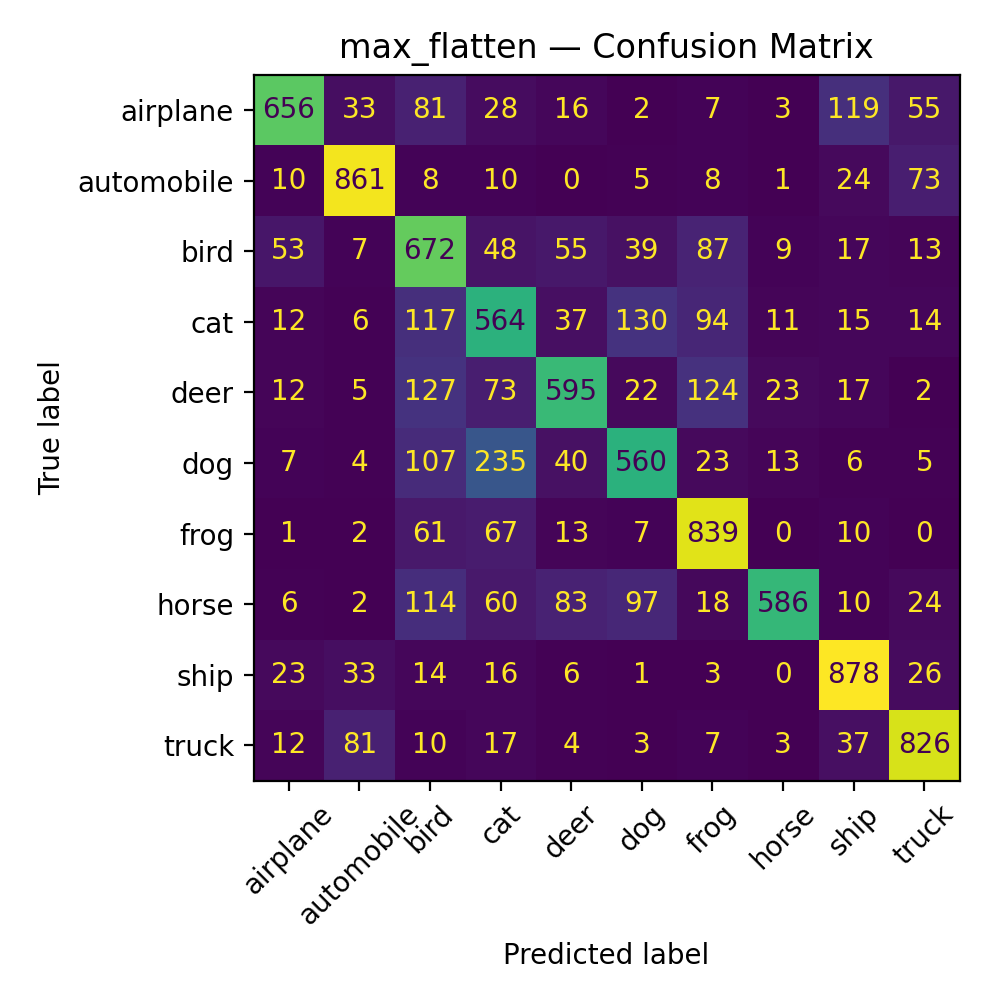

--- avg_flatten ---


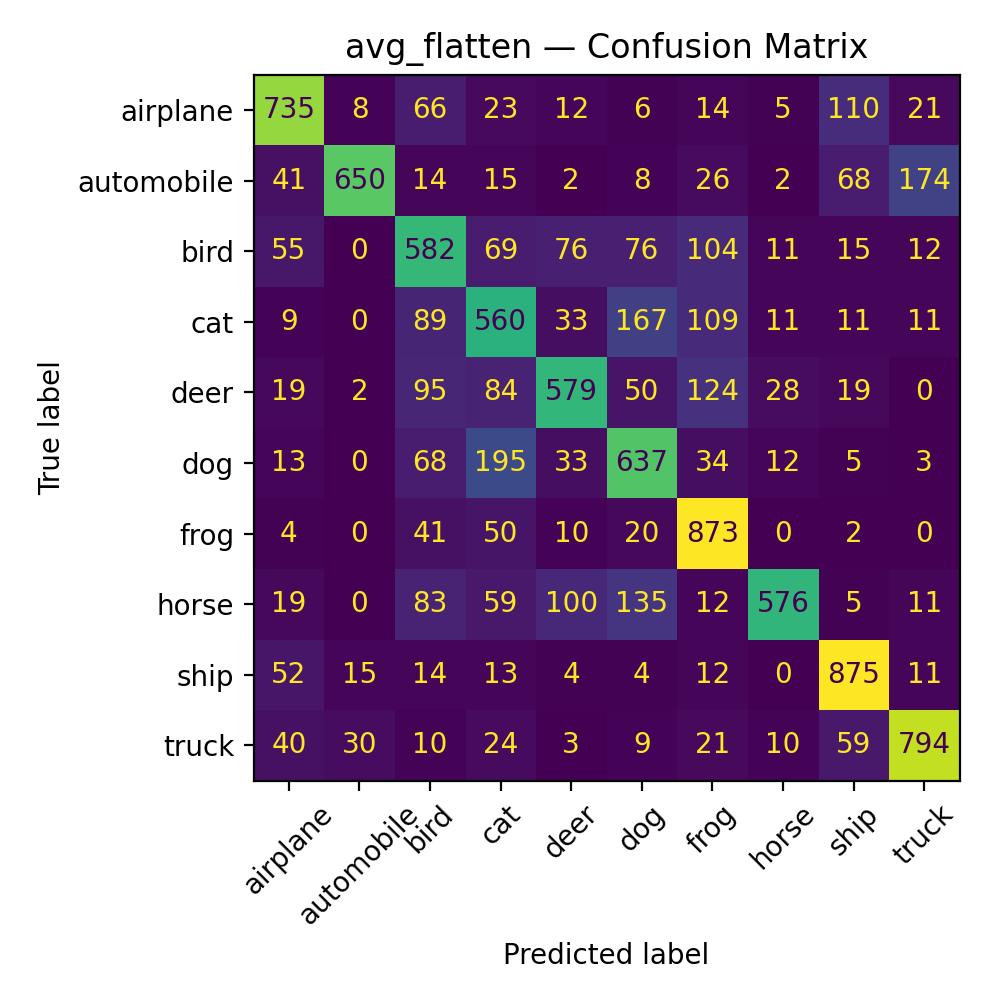

--- max_gap ---


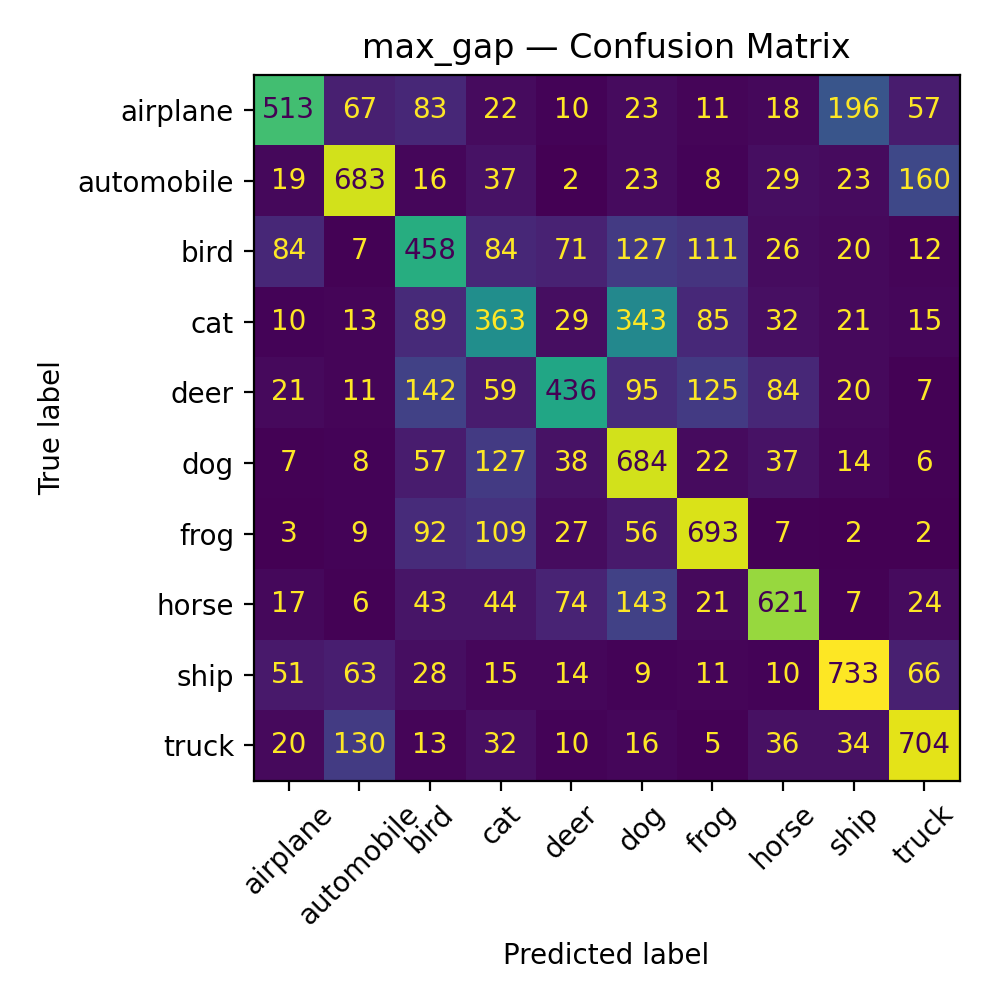

--- avg_gap ---


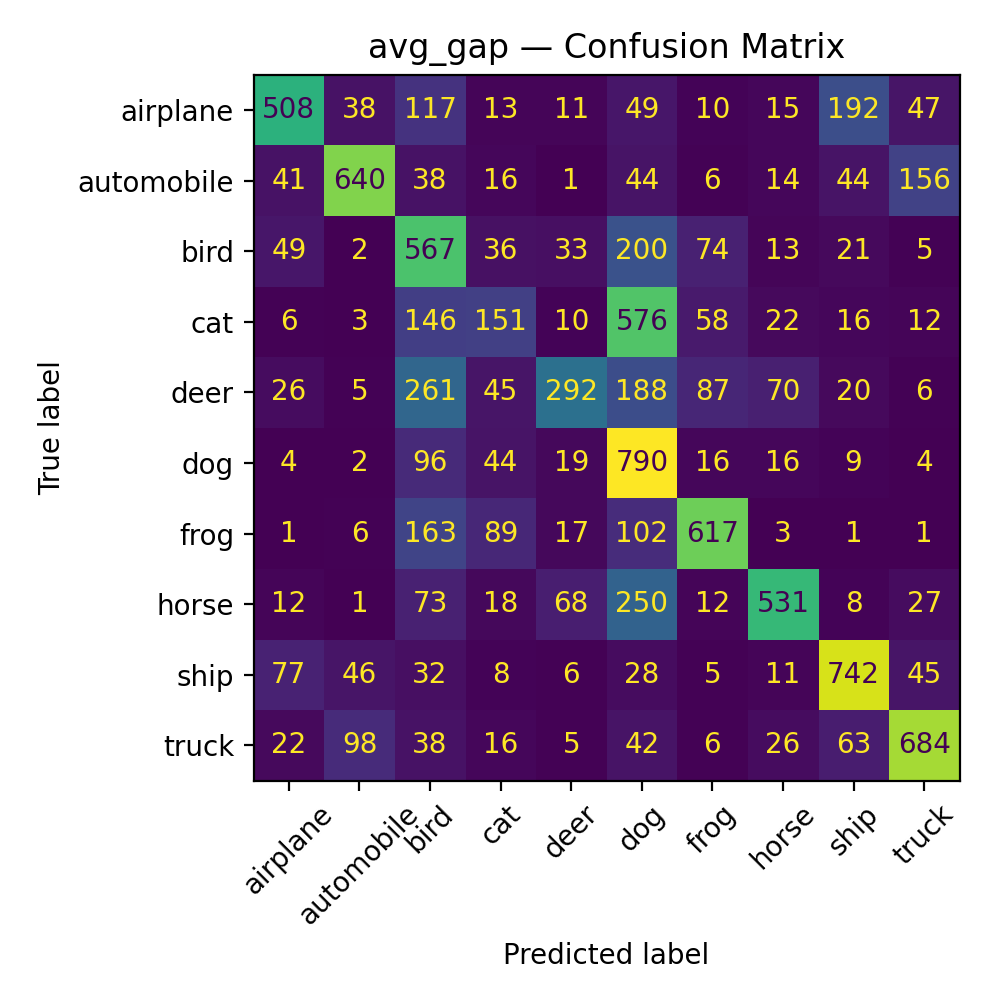

=== Training Curves (semua varian) ===
--- max_flatten ---


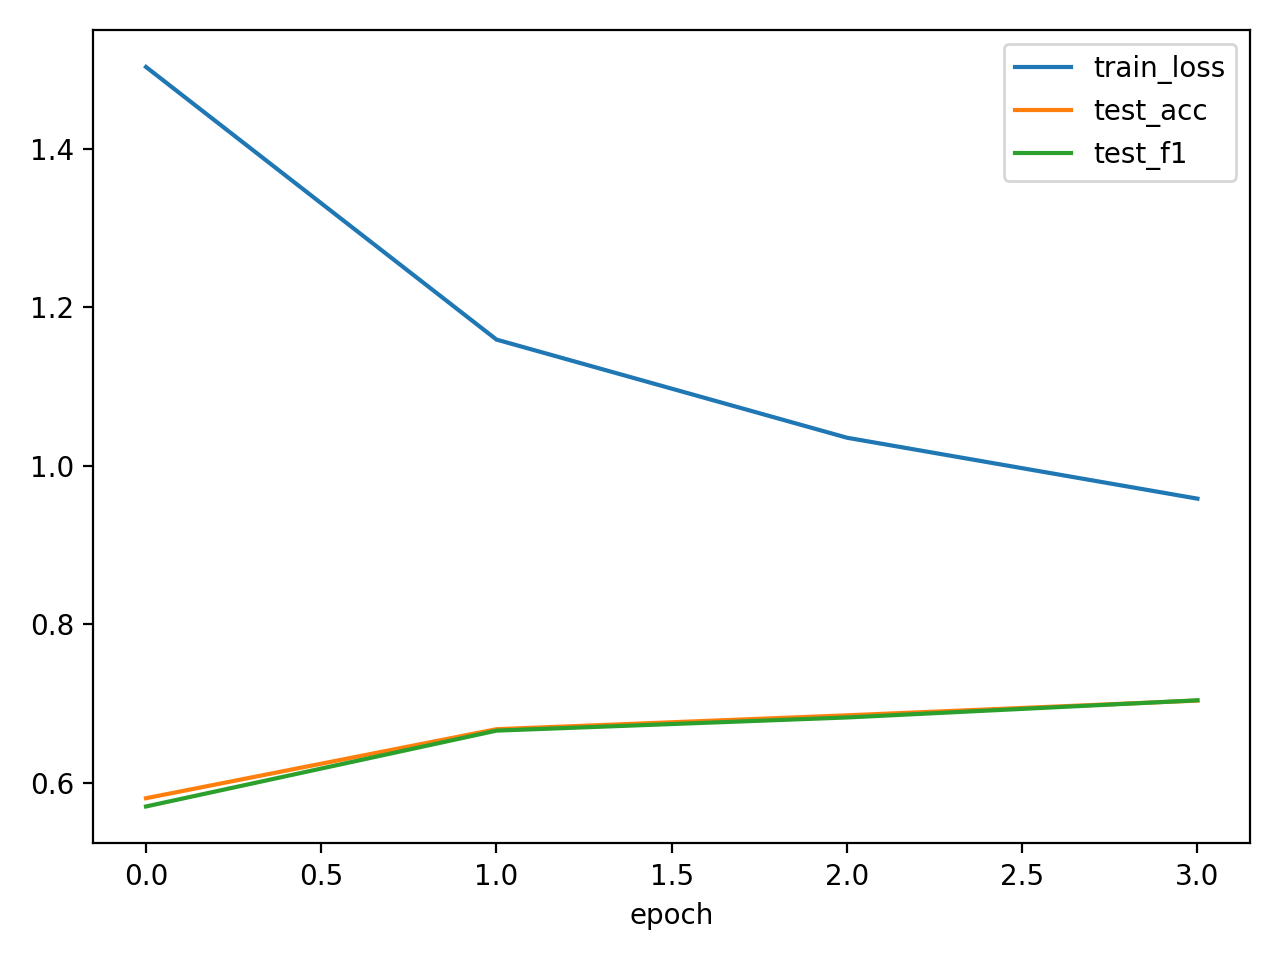

--- avg_flatten ---


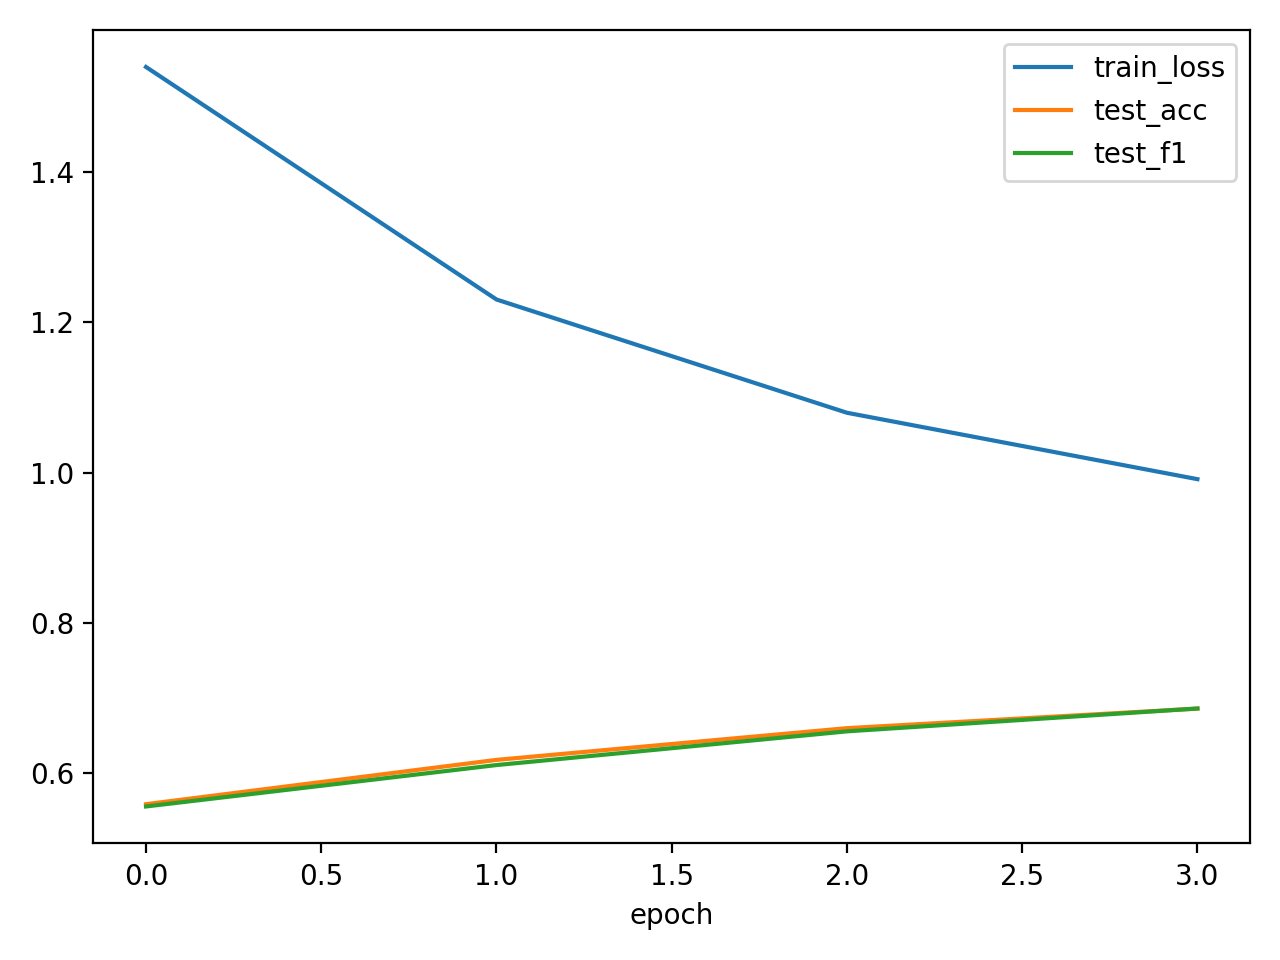

--- max_gap ---


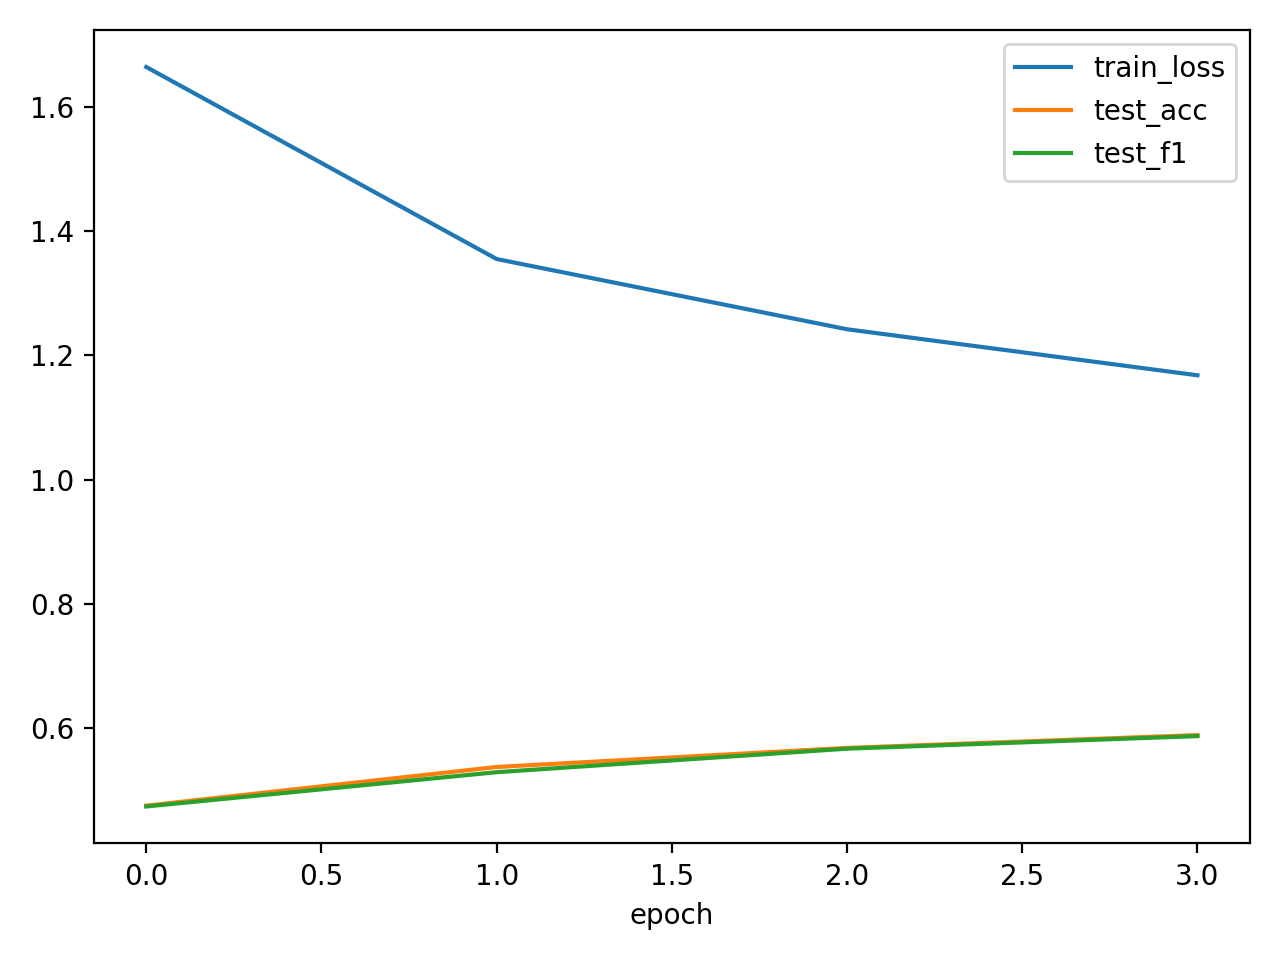

--- avg_gap ---


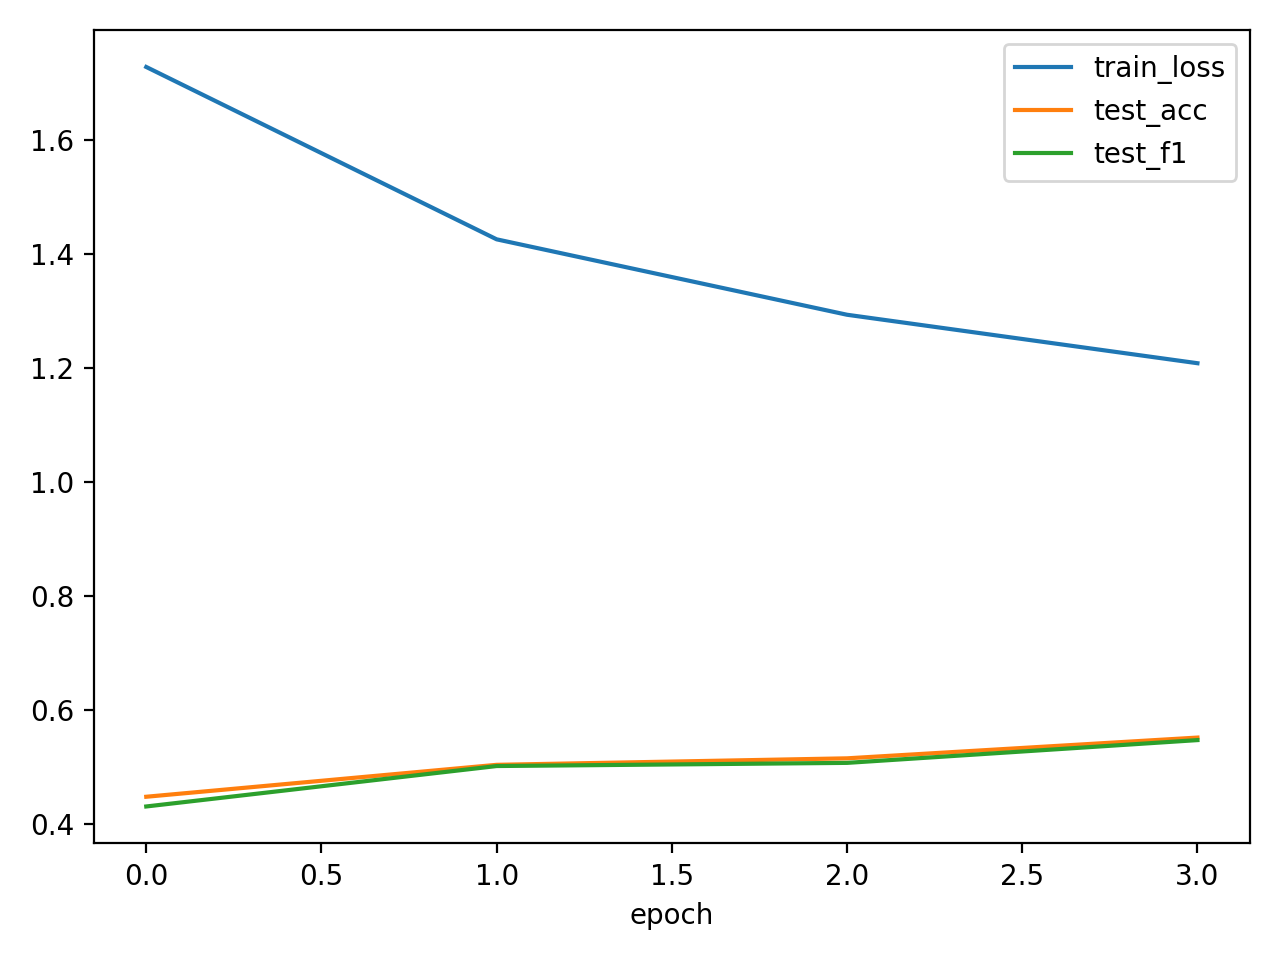

In [ ]:
print("=== Confusion Matrices (semua varian) ===")
for v in ["max_flatten", "avg_flatten", "max_gap", "avg_gap"]:
    print(f"--- {v} ---")
    display(Image(f'runs_cifar10/confusion_matrices/{v}_confmat.png'))

print("=== Training Curves (semua varian) ===")
for v in ["max_flatten", "avg_flatten", "max_gap", "avg_gap"]:
    print(f"--- {v} ---")
    display(Image(f'runs_cifar10/logs/{v}_curves.png'))

In [ ]:
import pandas as pd
df = pd.read_csv('runs_cifar10/results.csv')
print(df)

       variant     acc  macro_f1
0  max_flatten  0.6966  0.696431
1  avg_flatten  0.6892  0.690705
2      max_gap  0.5893  0.588019
3      avg_gap  0.5538  0.549092


In [ ]:
import shutil
from google.colab import files

# 1. Kompres folder cifar-10-batches-py menjadi cifar10.zip
shutil.make_archive('cifar10', 'zip', 'data/cifar-10-batches-py')

# 2. Download file zip ke komputer
files.download('cifar10.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/runs_cifar10",
    "zip",
    "/content",
    "runs_cifar10"
)

files.download("/content/runs_cifar10.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128
